
## Predicción de Precios de Casas - Ames Housing

**Dataset:** Ames Housing Dataset  
**Fuente:** https://www.kaggle.com/datasets/prevek18/ames-housing-dataset

## Variable objetivo (Y)
`SalePrice` — Precio de venta de la casa en USD

## Features seleccionadas (n=15)

| # | Feature | Descripción | Justificación |
|---|---|---|---|
| 1 | `Overall Qual` | Calidad general de la casa (1-10) | Mayor calidad implica mayor precio |
| 2 | `Gr Liv Area` | Área habitable sobre el nivel del suelo en pies² | Casas más grandes valen más |
| 3 | `Garage Cars` | Capacidad del garaje en número de autos | Más espacio para autos aumenta el valor |
| 4 | `Garage Area` | Área del garaje en pies² | Un garaje más grande añade valor |
| 5 | `Total Bsmt SF` | Área total del sótano en pies² | Más espacio de sótano aumenta el precio |
| 6 | `1st Flr SF` | Área del primer piso en pies² | Tamaño del piso principal afecta el valor |
| 7 | `Year Built` | Año de construcción | Casas más nuevas valen más |
| 8 | `Full Bath` | Número de baños completos | Más baños aumentan el precio |
| 9 | `Year Remod/Add` | Año de remodelación | Remodelaciones recientes añaden valor |
| 10 | `Mas Vnr Area` | Área de revestimiento de mampostería en pies² | Acabados de calidad aumentan precio |
| 11 | `TotRms AbvGrd` | Total de habitaciones sobre el nivel del suelo | Más habitaciones mayor valor |
| 12 | `Fireplaces` | Número de chimeneas | Chimeneas añaden valor a la casa |
| 13 | `BsmtFin SF 1` | Área de sótano terminado tipo 1 en pies² | Sótano terminado vale más |
| 14 | `Lot Frontage` | Pies lineales de calle conectados a la propiedad | Más frente de lote mayor valor |
| 15 | `Wood Deck SF` | Área de terraza de madera en pies² | Terrazas añaden valor |

## Columnas descartadas

| Columna | Razón |
|---|---|
| `Order` | Identificador — sin relación con el precio |
| `PID` | Identificador de parcela — sin relación con el precio |
| `MS SubClass` | Codificación — difícil de interpretar |
| Columnas categóricas | Se usan solo features numéricas para este ejercicio |
| Columnas con muchos nulos | Alley, Pool QC, Fence, Misc Feature — más del 50% nulos |

## Tres modelos a implementar
1. **Regresión Lineal Múltiple** con Descenso por Gradiente
2. **Regresión Polinómica** con Descenso por Gradiente
3. **Ecuación Normal** — solución exacta sin iteraciones

In [41]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

## 1. Carga del Dataset

Se carga el dataset usando Pandas. Se seleccionan las 15 features
numéricas con mayor correlación con SalePrice.
Se manejan valores nulos rellenando con la mediana.

In [18]:
# Cargar dataset
data = pd.read_csv('AmesHousing.csv')
#columnas 
columns = data.columns.tolist()
print(columns)

FEATURES = [
    'Overall Qual',
    'Gr Liv Area',
    'Garage Cars',
    'Garage Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Year Built',
    'Full Bath',
    'Year Remod/Add',
    'Mas Vnr Area',
    'TotRms AbvGrd',
    'Fireplaces',
    'BsmtFin SF 1',
    'Lot Frontage',
    'Wood Deck SF'
]

TARGET = 'SalePrice'

# Rellenar valores nulos con la mediana
for col in FEATURES:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Extraer X e y
X = data[FEATURES].values.astype(np.float64)
y = data[TARGET].values.astype(np.float64)
m = y.size

print(f'Dimensiones dataset : {data.shape}')
print(f'X shape             : {X.shape}')
print(f'y shape             : {y.shape}')
print(f'm                   : {m:,}')
print(f'n features          : {len(FEATURES)}')

['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

## 2. Exploración del Dataset

Se revisan estadísticas básicas para entender la distribución
de los datos antes de entrenar cualquier modelo.

In [17]:
print('=== Información general ===')
data.info()
print()
print('=== Estadísticas básicas ===')
data[FEATURES].describe()
print("*"*50)
data[TARGET].describe()

print(data[FEATURES].head())

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2930 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 1

In [33]:
np.random.seed(42)

# Mezclar indices aleatoriamente
indices = np.random.permutation(m)

# 75% entrenamiento, 25% validacion
split    = int(0.75 * m)
idx_entranamiento = indices[:split]
idx_validacion   = indices[split:]

X_entre = X[idx_entranamiento]
y_entre = y[idx_entranamiento]
X_vali   = X[idx_validacion]
y_vali   = y[idx_validacion]

m_entre = len(y_entre)
m_vali   = len(y_vali)

print(f'Ejemplos entrenamiento : {m_entre:,}')
print(f'Ejemplos validacion    : {m_vali:,}')

Ejemplos entrenamiento : 2,197
Ejemplos validacion    : 733


In [35]:
def featureNormalize(X):
    X_norm = X.copy()
    mu     = np.mean(X, axis=0)
    sigma  = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_entre_norm, mu, sigma = featureNormalize(X_entre)

# Aplicar mismos mu y sigma a validacion
X_vali_norm = (X_vali - mu) / sigma

print('Media (debe ser ≈ 0):')
print(np.mean(X_entre_norm, axis=0).round(4))
print()
print('Desv. estandar (debe ser ≈ 1):')
print(np.std(X_entre_norm, axis=0).round(4))

Media (debe ser ≈ 0):
[-0. -0.  0. -0.  0. -0. -0.  0.  0. -0.  0.  0.  0.  0.  0.]

Desv. estandar (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [36]:
# Agregar columna de unos a entrenamiento y validacion
X_entre = np.concatenate([np.ones((m_entre, 1)), X_entre_norm], axis=1)
X_vali   = np.concatenate([np.ones((m_vali,   1)), X_vali_norm],   axis=1)

print(f'X_train shape: {X_entre.shape}')
print(f'X_val shape  : {X_vali.shape}')

X_train shape: (2197, 16)
X_val shape  : (733, 16)


In [37]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

# Costo inicial con theta ceros
theta = np.zeros(X_entre.shape[1])
J     = computeCostMulti(X_entre, y_entre, theta)
print('Con theta ceros')
print('Costo inicial = %.2f' % J)

Con theta ceros
Costo inicial = 19770718517.00


In [38]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m     = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

In [39]:
alpha     = 0.1
num_iters = 400
theta     = np.zeros(X_entre.shape[1])

theta, J_history = gradientDescentMulti(X_entre, y_entre, theta, alpha, num_iters)

J_train = computeCostMulti(X_entre, y_entre, theta)
J_val   = computeCostMulti(X_vali,   y_vali,   theta)

print('=== Regresión Lineal Múltiple ===')
print('Costo inicial      : %.2f' % J_history[0])
print('Costo entrenamiento: %.2f' % J_train)
print('Costo validacion   : %.2f' % J_val)

=== Regresión Lineal Múltiple ===
Costo inicial      : 14451570588.50
Costo entrenamiento: 591466954.05
Costo validacion   : 591175842.67


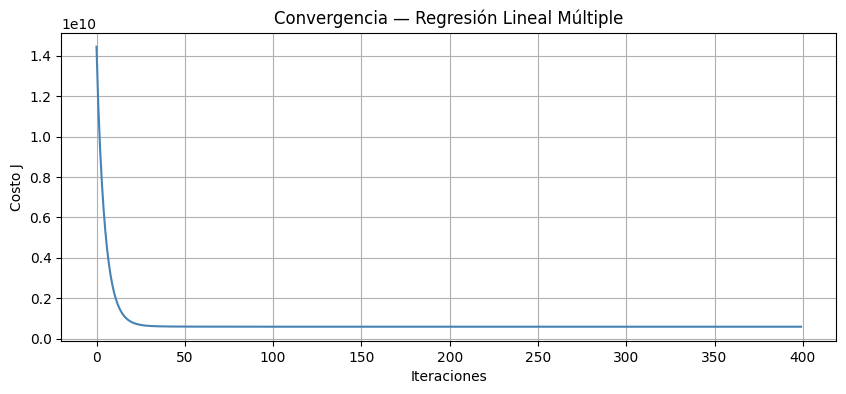

In [40]:
pyplot.figure(figsize=(10, 4))
pyplot.plot(np.arange(len(J_history)), J_history, color='steelblue')
pyplot.xlabel('Iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia — Regresión Lineal Múltiple')
pyplot.grid(True)
pyplot.show()